In [265]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Section I: Preprocessing

In [266]:
# Load dataset

df = pd.read_csv("datasets/healthcare-dataset-stroke-data.csv")

In [267]:
# Shape if the dataset

print(f"Rows: {df.shape[0]}\nColumns: {df.shape[1]}")

Rows: 5110
Columns: 12


In [268]:
# Display first 5 rows

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [269]:
# Check Null Values

total_null = np.sum(df.isnull().sum().values)
df.isnull().sum() / total_null * 100

id                     0.0
gender                 0.0
age                    0.0
hypertension           0.0
heart_disease          0.0
ever_married           0.0
work_type              0.0
Residence_type         0.0
avg_glucose_level      0.0
bmi                  100.0
smoking_status         0.0
stroke                 0.0
dtype: float64

In [270]:
# Check duplicate rows

df.duplicated().sum()

0

In [271]:
# Extract a numerical copy of the dataset

df_numerical = df.select_dtypes(include="number").copy()

In [272]:
# Check skew 

df_numerical.skew()

id                  -0.019913
age                 -0.137059
hypertension         2.715392
heart_disease        3.947244
avg_glucose_level    1.572284
bmi                  1.055340
stroke               4.193284
dtype: float64

In [273]:
# Drop missing BMI columns

df.dropna(subset=["bmi"], axis=0, inplace=True)

In [274]:
# Drop rows where smoking status is unknown

df = df[df['smoking_status'] != 'Unknown']

Index([0, 1], dtype='int64', name='stroke')


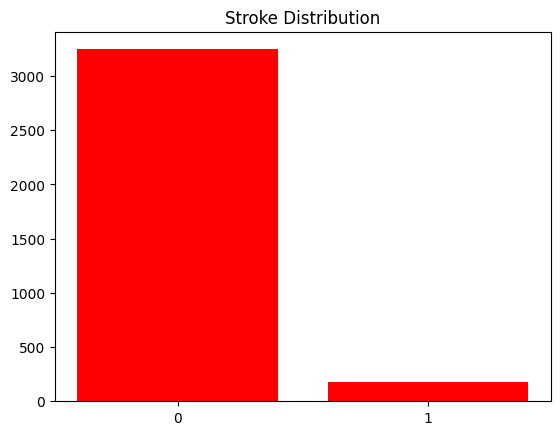

In [275]:
# Check distribution of the stroke column

stroke_dist = df["stroke"].value_counts()

print(stroke_dist.index)

plt.bar(stroke_dist.index.astype(str), stroke_dist.values, color="red")
plt.title("Stroke Distribution")
plt.show()

## Section II: EDA

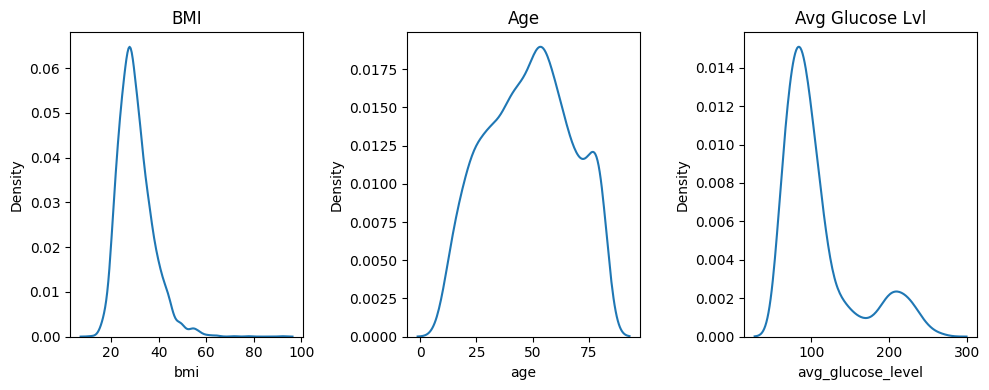

In [276]:
# Distributions for age, bmi, and avg_glucose_level

fig, ax = plt.subplots(1, 3, figsize=(10, 4))

sns.kdeplot(data=df, x="bmi", ax=ax[0])
ax[0].set_title("BMI")

sns.kdeplot(data=df, x="age", ax=ax[1])
ax[1].set_title("Age")

sns.kdeplot(data=df, x="avg_glucose_level", ax=ax[2])
ax[2].set_title("Avg Glucose Lvl")

plt.tight_layout()
plt.show()

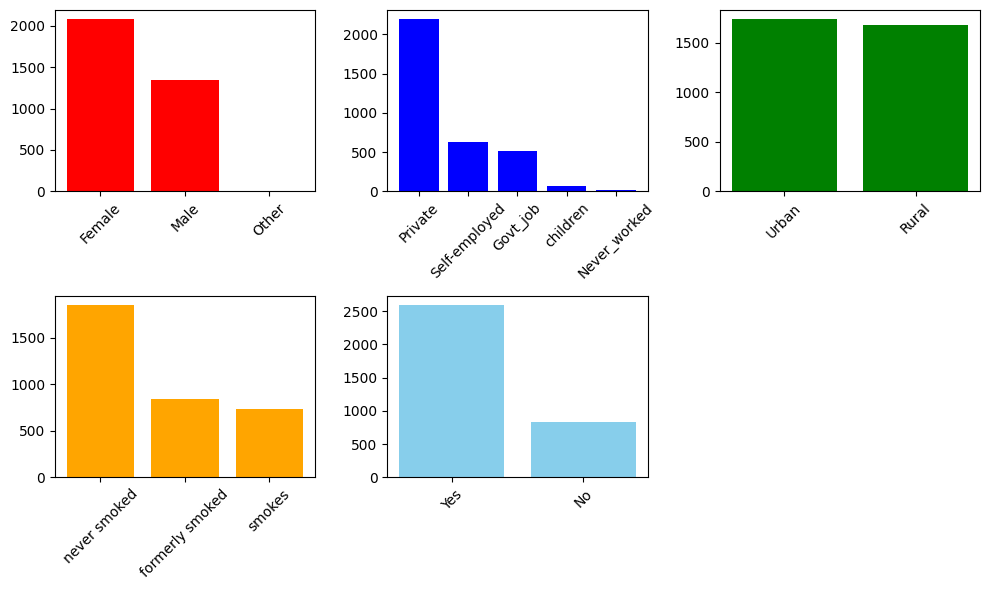

In [277]:
# See the distributions of the categorical columns

selected_categories = ['gender', 'work_type', 'Residence_type', 'smoking_status', 'ever_married']
colors = ['red', 'blue', 'green', 'orange', 'skyblue']

selected_categories = df[selected_categories].copy()

selected_categories.head()

fig, ax = plt.subplots(2, 3, figsize=(10, 6))

j = 0
k = 0

for idx, col_name in enumerate(selected_categories.columns):
    curr_category = selected_categories[col_name].value_counts()

    r = idx // 3
    c = idx % 3 

    ax[r][c].bar(curr_category.index, curr_category.values, color=colors[idx])

    # Rotate the tick labels
    ax[r][c].tick_params(axis="x", labelrotation=45)


# Delete the last axis
fig.delaxes(ax[1][2])

plt.tight_layout()
plt.show()

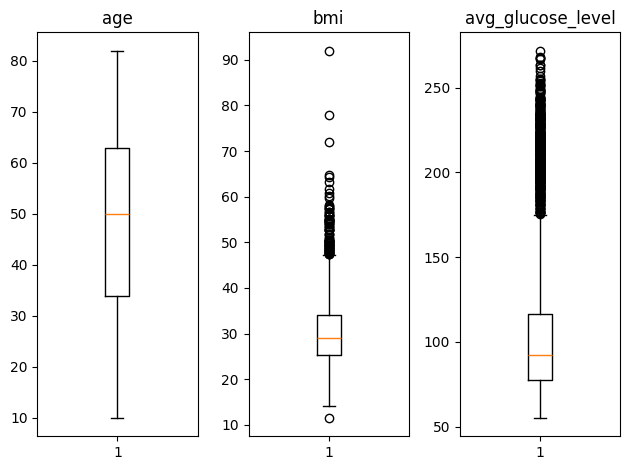

In [278]:
# age, avg_glucose_level, and bmi

selected_cols = ['age', 'bmi', 'avg_glucose_level']
    
colors = ['red', 'blue', 'green']
selected_cols = df[selected_cols].copy()


fig, ax = plt.subplots(1, 3)

for idx, col_name in enumerate(selected_cols):
    curr_col_values = selected_cols[col_name].values
    ax[idx].boxplot(curr_col_values)
    ax[idx].set_title(col_name)

plt.tight_layout()
plt.show()

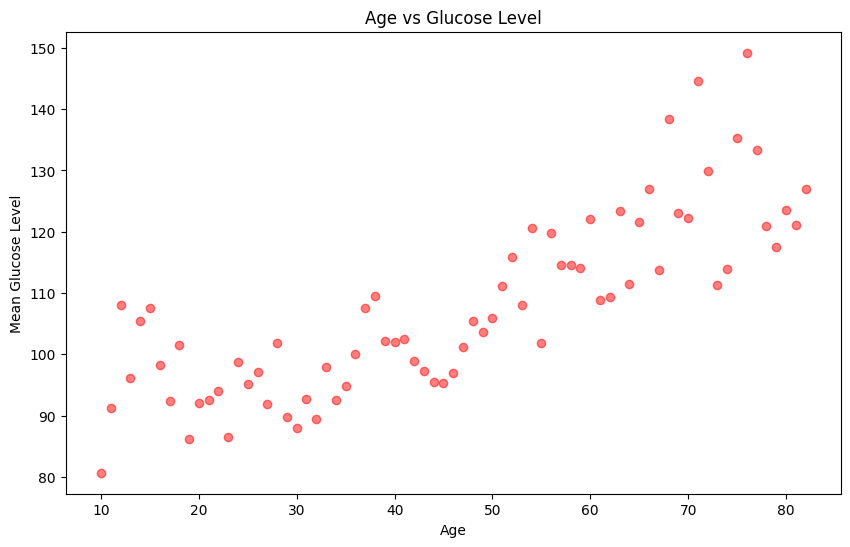

In [279]:
# Plot the relationship b/w age and glucose level

age_gluc = df.groupby('age')['avg_glucose_level'].mean()

plt.figure(figsize=(10, 6))
plt.scatter(age_gluc.index, age_gluc.values, alpha=0.5, color="red")
plt.title("Age vs Glucose Level")
plt.xlabel("Age")
plt.ylabel("Mean Glucose Level")
plt.show()

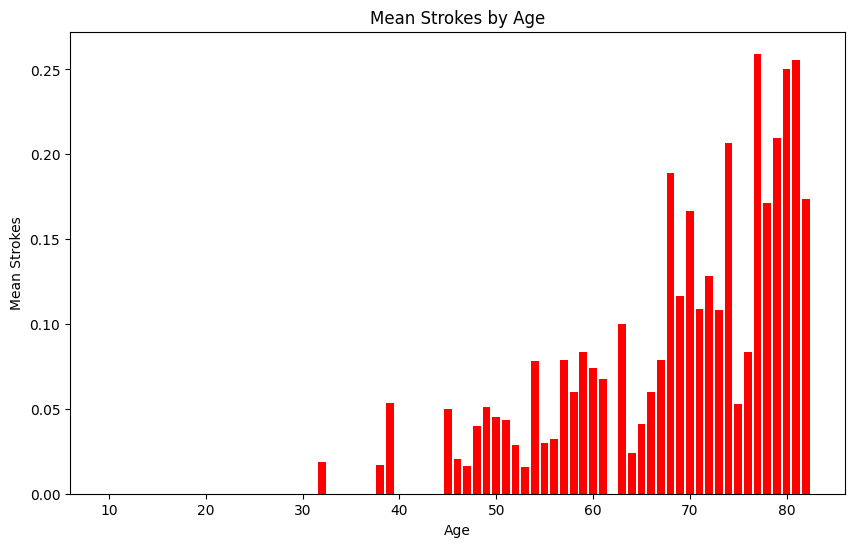

In [280]:
# Plot the relationship between Age and Stroke 

strokes_per_age = df.groupby('age')['stroke'].mean()
plt.figure(figsize=(10, 6))
plt.bar(strokes_per_age.index, strokes_per_age.values, color="red")
plt.title("Mean Strokes by Age")
plt.xlabel("Age")
plt.ylabel("Mean Strokes")
plt.show()

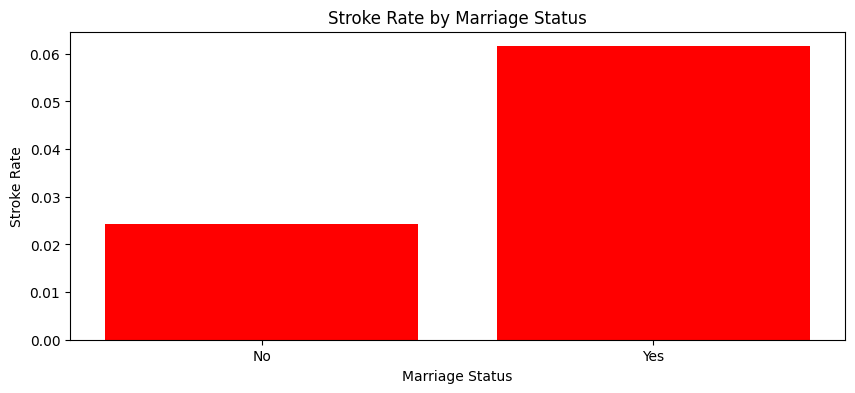

In [281]:
# Relationship between marriage and strokes 

strokes_by_married = df.groupby("ever_married")['stroke'].mean()

plt.figure(figsize=(10, 4))
plt.bar(strokes_by_married.index, strokes_by_married.values, color="red")
plt.title("Stroke Rate by Marriage Status")
plt.xlabel("Marriage Status")
plt.ylabel("Stroke Rate")
plt.show()


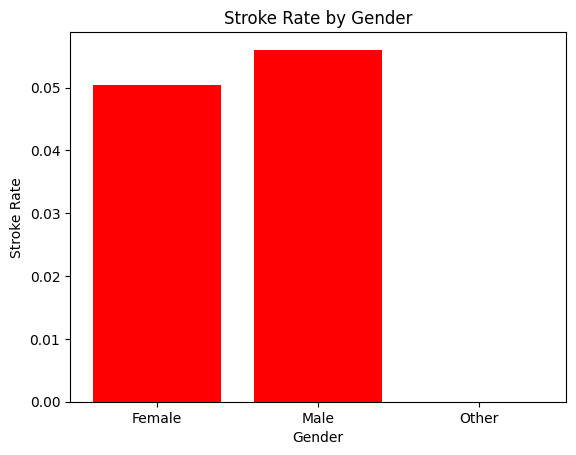

In [282]:
# Stroke rate by gender

strokes_per_gender = df.groupby('gender')['stroke'].mean()

plt.bar(strokes_per_gender.index, strokes_per_gender.values, color="red")
plt.title("Stroke Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Stroke Rate")
plt.show()

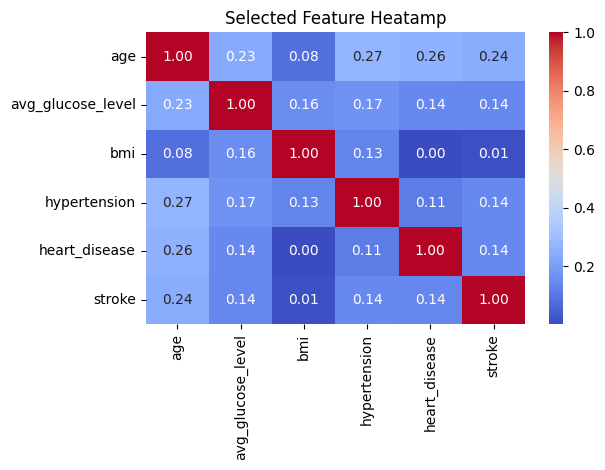

In [283]:
# age, avg_glucose_level, bmi, hypertension, heart_disease) plus stroke.

selected_cols = ['age', 'avg_glucose_level', 'bmi', 'hypertension', 'heart_disease', 'stroke']
selected_cols = df[selected_cols].copy()

_corr = selected_cols.corr()

plt.title("Selected Feature Heatamp")
sns.heatmap(_corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.tight_layout()
plt.show()

## Section III: Model Preprocessing

In [284]:
# Encode the dataset

from sklearn.preprocessing import LabelEncoder, OneHotEncoder

le = LabelEncoder()
ohe = OneHotEncoder(sparse_output=False).set_output(transform="pandas")

label_cols = ['ever_married', 'Residence_type']
oh_cols = ['gender', 'work_type', 'smoking_status']

df_labels = df[label_cols].copy()

for col in label_cols:
    df[col] = le.fit_transform(df_labels[col])

for col in oh_cols:
    oh_col = ohe.fit_transform(df[[col]])
    df.drop(col, axis=1, inplace=True)
    df = pd.concat([df, oh_col], axis=1)

stroke_col = df['stroke']
df = df.drop("stroke", axis=1)

df = pd.concat([df, stroke_col], axis=1)

df.head()

,id,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,9046,67.0,0,1,1,1,228.69,36.6,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
2,31112,80.0,0,1,1,0,105.92,32.5,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1
3,60182,49.0,0,0,1,1,171.23,34.4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1
4,1665,79.0,1,0,1,0,174.12,24.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1
5,56669,81.0,0,0,1,1,186.21,29.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1


In [285]:
# Extract the dataset into features and output

X = df.iloc[:, :-1]
y = df.iloc[:, -1]

In [286]:
# Standard Scale the dataset and make a separate df_scaled for linear models

from sklearn.preprocessing import StandardScaler
X_copy = X.copy()

ss = StandardScaler()
X_scaled = ss.fit_transform(X_copy)

In [287]:
# Separate into train and test data

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
Xl_train, Xl_test, yl_train, yl_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

## Section IV: Model Application

In [288]:
# Apply the Logistic Regression model

from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression()
log_reg.fit(Xl_train, yl_train)

y_pred_log_reg = log_reg.predict(Xl_test)

In [289]:
# Apply the Classification Tree Model

from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier(criterion='entropy')
dec_tree.fit(X_train, y_train)

y_pred_dec_tree = dec_tree.predict(X_test)

In [290]:
# Apply the Random Forest Model

from sklearn.ensemble import RandomForestClassifier

rand_forest = RandomForestClassifier(criterion='entropy')
rand_forest.fit(X_train, y_train)

y_pred_rand_forest = rand_forest.predict(X_test)

In [291]:
# Apply Linear SVC

from sklearn.svm import LinearSVC

svc = LinearSVC()
svc.fit(Xl_train, yl_train)

y_pred_svc = svc.predict(Xl_test)

In [292]:
# Apply K Nearest Neighbors

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(Xl_train, yl_train)

y_pred_knn = knn.predict(Xl_test)

## Section V: Model Analysis

In [293]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay

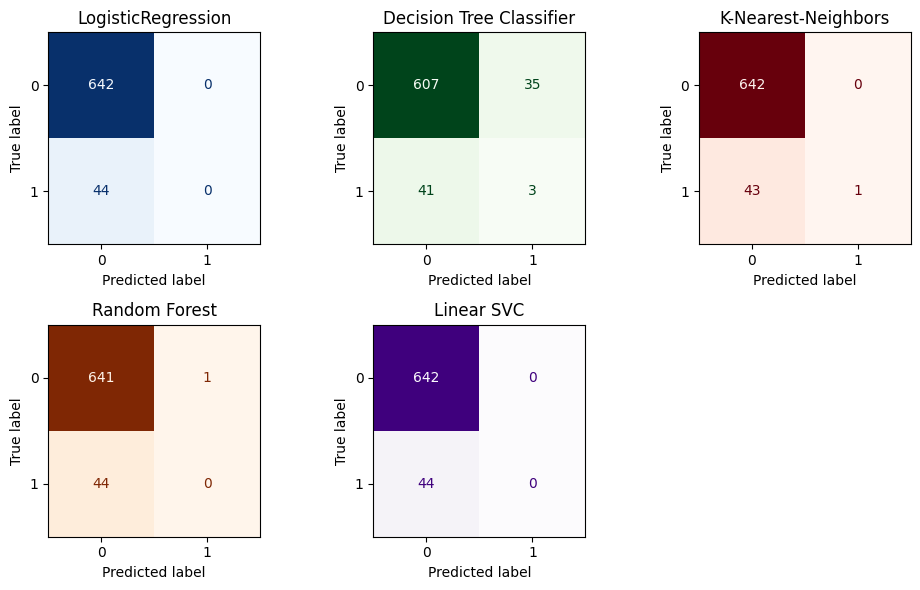

In [294]:
# Plot the confusion matrices for each model

y_pred = [y_pred_log_reg, y_pred_dec_tree, y_pred_knn, y_pred_rand_forest, y_pred_svc]
estimators = [log_reg, dec_tree, knn, rand_forest, svc]
models = ['LogisticRegression', 'Decision Tree Classifier', 'K-Nearest-Neighbors', 'Random Forest', 'Linear SVC']
cmaps = ['Blues', 'Greens', 'Reds', 'Oranges', 'Purples']

fig, ax = plt.subplots(2, 3, figsize=(10, 6))

for idx, estimator in enumerate(estimators):
    r = idx // 3
    c = idx % 3

    ConfusionMatrixDisplay.from_estimator(
        estimator, 
        X_test if estimator in [dec_tree, rand_forest] else Xl_test,
        y_test if estimator in [dec_tree, rand_forest] else yl_test,
        ax=ax[r][c],
        cmap=cmaps[idx],
        colorbar=False
    )
    ax[r][c].set_title(models[idx])

plt.delaxes(ax[1][2])
plt.tight_layout()
plt.show()

In [295]:
# Find the best model via KFold Cross Validation

from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=10)

cvscores = [
    np.mean(cross_val_score(
            e, 
            X_train if e in [dec_tree, rand_forest] else Xl_train, 
            y_train if e in [dec_tree, rand_forest] else yl_train,
            cv=kf,
            scoring="recall"
        ))
        for e in estimators
]

best_model = models[np.argmax(cvscores)]

print(f"The best model for this dataset is: {best_model}")

The best model for this dataset is: Decision Tree Classifier


In [ ]:
# Optimize the decision tree model with GridSearchCV

from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': range(3, 11),
    'min_samples_split': [2, 5, 10, 20, 50]
}

optimal_dec_tree = DecisionTreeClassifier()

grid_search = GridSearchCV(optimal_dec_tree, param_grid=param_grid, cv=kf, scoring='recall')
grid_search.fit(X_train, y_train)

optimal_dec_tree = grid_search.best_estimator_

optimal_dec_tree

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


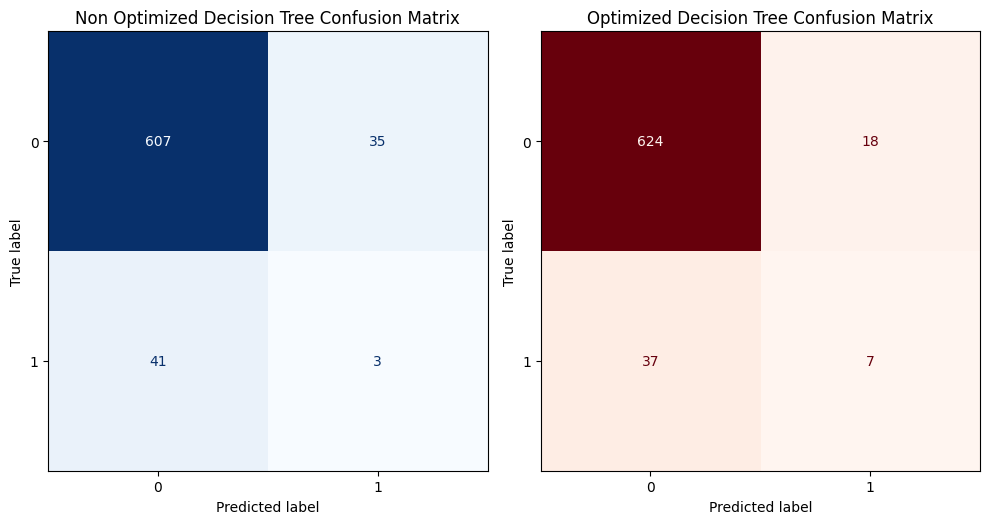

In [ ]:
# Plot confusion matrices of optimal vs non-optimal model

fig, ax = plt.subplots(1, 2, figsize=(10, 6))
ConfusionMatrixDisplay.from_estimator(dec_tree, X_test, y_test, cmap='Blues', colorbar=False, ax=ax[0])
ax[0].set_title('Non Optimized Decision Tree Confusion Matrix')
ConfusionMatrixDisplay.from_estimator(optimal_dec_tree, X_test, y_test, cmap='Reds', colorbar=False, ax=ax[1])
ax[1].set_title('Optimized Decision Tree Confusion Matrix')

plt.tight_layout()
plt.show()

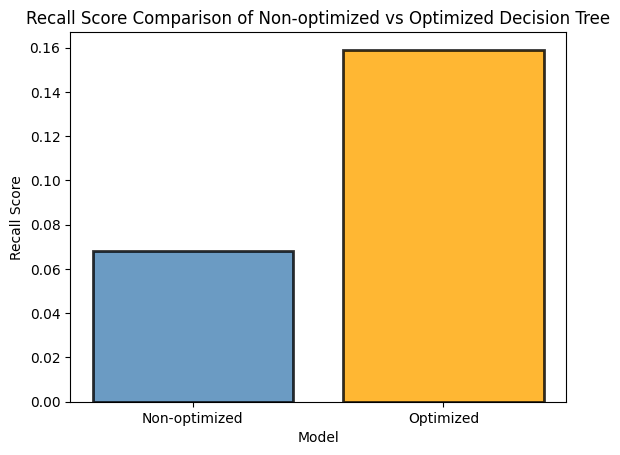

In [ ]:
# Compare recall scores

from sklearn.metrics import recall_score

y_pred_og = dec_tree.predict(X_test)
y_pred_opt = optimal_dec_tree.predict(X_test)

labels = ['Non-optimized', 'Optimized']
values = [recall_score(y_test, y_pred_og), recall_score(y_test, y_pred_opt)]

plt.bar(labels, values, color=['steelblue', 'orange'], linewidth=2, edgecolor='black', alpha=0.8)
plt.title('Recall Score Comparison of Non-optimized vs Optimized Decision Tree')
plt.xlabel('Model')
plt.ylabel('Recall Score')
plt.show()